# Correlation

Inputs: data/clean.parquet

Outputs: 
- outputs/correlation_matrix.csv
- outputs/fig_hlc_vs_y.png
- outputs/evidence_correlation.json

### Section 0: Setup

In [45]:
import json
import os
import pathlib
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

# Constants:
PROJECT_ROOT = pathlib.Path().resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data"
DEFAULT_ROUNDING_DECIMALS = 4
RANDOM_SEED = 20008
CORRELATION_VARIABLES = ["host_listings_count", "days_since_last_review", "availability_365", "dist_cbd", "y"]


# Utility function used to round a value to a given number of places
def round_value(value, digits=DEFAULT_ROUNDING_DECIMALS):
    return round(float(value), digits)


# Listings dataframe
listings = pd.read_parquet(DATA_DIR / "clean.parquet")
listings = listings[listings["has_review"] == 1]


# Helper function that discretizes a continuous feature into
# discrete equal-frequency bins
def equal_frequency_bin(column, n_bins=10):
    # If the column is not continuous ('y' is already 0/1) don't do anything
    if column.nunique() <= 2:
        return column
    else:
        # Cut the data into 'n_bins' bins
        # labels=False returns bin numbers 0,1,2,...
        return pd.qcut(column, n_bins, labels=False, duplicates="drop")


evidence = {"n_rows": len(listings)}

### Section 1: Evidence for binning decisions

In [46]:
# Distribution data for methodology
evidence["percentiles"] = listings[["host_listings_count", "days_since_last_review"]].quantile([0.5, 0.75, 1]).to_dict()
evidence["av365_share_0"] = round_value((listings["availability_365"] == 0).mean())
evidence["av365_share_365"] = round_value((listings["availability_365"] == 365).mean())

# Why we use equal frequency rather than equal width
evidence["hlc_equal_width_max_bin"] = {n_bins: round_value(pd.cut(listings["host_listings_count"], n_bins).value_counts(normalize=True).max()) for n_bins in (10, 20)}

# Why we only compare NMI across pairs
dsl_column, availability_column = listings["days_since_last_review"], listings["availability_365"]
evidence["mi_bin_sensitivity"] = {
    n_bins: {
        "mi": round_value(mutual_info_score(equal_frequency_bin(dsl_column, n_bins), equal_frequency_bin(availability_column, n_bins))),
        "nmi": round_value(normalized_mutual_info_score(equal_frequency_bin(dsl_column, n_bins), equal_frequency_bin(availability_column, n_bins))),
    }
    for n_bins in (5, 10, 20, 40)
}

evidence

{'n_rows': 21251,
 'percentiles': {'host_listings_count': {0.5: 2.0, 0.75: 14.0, 1.0: 667.0},
  'days_since_last_review': {0.5: 84.0, 0.75: 448.0, 1.0: 4593.0}},
 'av365_share_0': 0.2176,
 'av365_share_365': 0.0156,
 'hlc_equal_width_max_bin': {10: 0.9143, 20: 0.8456},
 'mi_bin_sensitivity': {5: {'mi': 0.1175, 'nmi': 0.0799},
  10: {'mi': 0.1829, 'nmi': 0.0856},
  20: {'mi': 0.2499, 'nmi': 0.0896},
  40: {'mi': 0.3084, 'nmi': 0.0902}}}

### Section 2. Table 1 (5 variables, 4 correlation measures)

In [47]:
table_rows = []
for variable_a, variable_b in combinations(CORRELATION_VARIABLES, 2):
    binned_a, binned_b = equal_frequency_bin(listings[variable_a]), equal_frequency_bin(listings[variable_b])
    table_rows.append(
        {
            "pair": f"{variable_a} ~ {variable_b}",
            "pearson": round_value(listings[variable_a].corr(listings[variable_b]), 3),
            "spearman": round_value(listings[variable_a].corr(listings[variable_b], method="spearman"), 3),
            "mi": round_value(mutual_info_score(binned_a, binned_b)),
            "nmi": round_value(normalized_mutual_info_score(binned_a, binned_b)),
            "bins": f"{binned_a.nunique()}×{binned_b.nunique()}",
        }
    )

# Sort table by NMI descending
correlation_table = pd.DataFrame(table_rows).sort_values("nmi", ascending=False)

correlation_table

,pair,pearson,spearman,mi,nmi,bins
4,days_since_last_review ~ availability_365,-0.438,-0.395,0.1829,0.0856,10×8
6,days_since_last_review ~ y,-0.337,-0.443,0.1159,0.0785,10×2
8,availability_365 ~ y,0.146,0.155,0.0425,0.0324,8×2
2,host_listings_count ~ dist_cbd,-0.131,-0.225,0.0580,0.0285,7×10
0,host_listings_count ~ days_since_last_review,-0.113,-0.194,0.0558,0.0274,7×10
1,host_listings_count ~ availability_365,0.059,0.225,0.0430,0.0230,7×8
7,availability_365 ~ dist_cbd,0.170,0.124,0.0315,0.0147,8×10
5,days_since_last_review ~ dist_cbd,-0.081,0.061,0.0317,0.0138,10×10
3,host_listings_count ~ y,-0.069,0.070,0.0117,0.0097,7×2
9,dist_cbd ~ y,0.076,0.009,0.0070,0.0047,10×2


### Section 3: Finding disagreements between Pearson and Spearman

In [48]:
# A series of the absolute distances between Pearson and Spearman correlation coefficients
pearson_spearman_gap = (correlation_table["spearman"] - correlation_table["pearson"]).abs()

# Find the largest gap within the series
largest_gap_idx = int(pearson_spearman_gap.to_numpy().argmax())
largest_gap_pair = correlation_table.iloc[largest_gap_idx]["pair"]

# Largest gap evidence:
evidence["max_gap"] = {largest_gap_pair: round_value(pearson_spearman_gap.max(), 3)}
# Pearson & Spearman having opposite signs:
evidence["sign_flip_pairs"] = correlation_table.loc[correlation_table["pearson"] * correlation_table["spearman"] < 0, "pair"].tolist()

evidence["max_gap"]

{'host_listings_count ~ availability_365': 0.166}

### Section 4: Host scale vs superhost rate

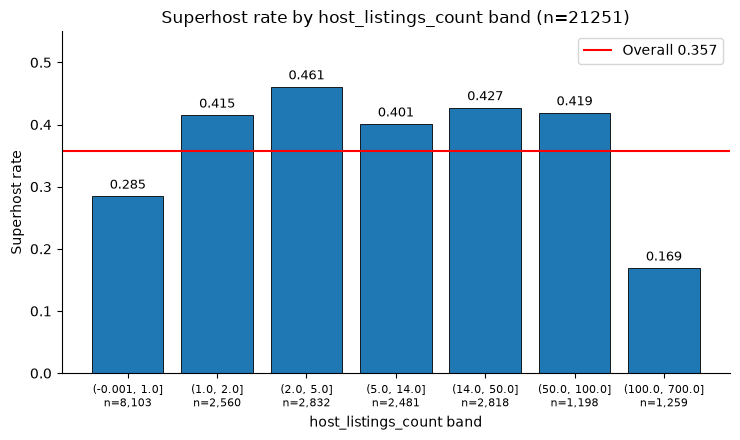

In [49]:
overall_superhost_rate = listings["y"].mean()
host_size_bands = listings.groupby(pd.cut(listings["host_listings_count"], [0, 1, 2, 5, 14, 50, 100, 700], include_lowest=True), observed=True)["y"].agg(n="size", rate="mean")
host_size_bands.index = host_size_bands.index.astype(str)
evidence["hlc_band"] = host_size_bands.round(DEFAULT_ROUNDING_DECIMALS).to_dict()

# Figure drawing
figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.bar(range(len(host_size_bands)), host_size_bands["rate"], edgecolor="black", linewidth=0.6)
axis.axhline(overall_superhost_rate, color="red", label=f"Overall {overall_superhost_rate:.3f}")
for bar_position, band_rate in enumerate(host_size_bands["rate"]):
    axis.text(bar_position, band_rate + 0.012, f"{band_rate:.3f}", ha="center", fontsize=9)
axis.set_xticks(range(len(host_size_bands)))
axis.set_xticklabels([f"{band}\nn={count:,}" for band, count in zip(host_size_bands.index, host_size_bands["n"])], fontsize=8)
axis.set(ylim=(0, 0.55), xlabel="host_listings_count band", ylabel="Superhost rate", title=f"Superhost rate by host_listings_count band (n={len(listings)})")
axis.legend(loc="upper right")
axis.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_hlc_vs_y.png", dpi=150)
plt.close(figure)

figure

### Section 5: Save 

In [50]:
# Save correlation matrix CSV
correlation_table.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix.csv"), index=False)

# Save evidence JSON
with open(os.path.join(OUTPUT_DIR, "evidence_correlation.json"), "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

print(correlation_table.to_string(index=False))

                                        pair  pearson  spearman     mi    nmi  bins
   days_since_last_review ~ availability_365   -0.438    -0.395 0.1829 0.0856  10×8
                  days_since_last_review ~ y   -0.337    -0.443 0.1159 0.0785  10×2
                        availability_365 ~ y    0.146     0.155 0.0425 0.0324   8×2
              host_listings_count ~ dist_cbd   -0.131    -0.225 0.0580 0.0285  7×10
host_listings_count ~ days_since_last_review   -0.113    -0.194 0.0558 0.0274  7×10
      host_listings_count ~ availability_365    0.059     0.225 0.0430 0.0230   7×8
                 availability_365 ~ dist_cbd    0.170     0.124 0.0315 0.0147  8×10
           days_since_last_review ~ dist_cbd   -0.081     0.061 0.0317 0.0138 10×10
                     host_listings_count ~ y   -0.069     0.070 0.0117 0.0097   7×2
                                dist_cbd ~ y    0.076     0.009 0.0070 0.0047  10×2
